# Explore Clean Data
**Goal**: EDA on cleaned dataset — distributions, correlations, target analysis, visual insights for feature selection.

---

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import yaml

## 1. Load Clean Data

In [2]:
def read_file(yaml_path, inp_data_section, file_name):
    """Load a CSV whose path is stored in a YAML config.
    Returns a DataFrame, or None on a handled error."""

    #Read the YAML config
    try:
        with open(yaml_path, "r") as file:
            cfg = yaml.safe_load(file)
    except FileNotFoundError:
        print(f"Config file not found: {yaml_path}")
        return None
    except yaml.YAMLError as e:
        print(f"Could not parse YAML: {e}")
        return None

    #Look up the CSV path inside the config
    try:
        csv_path = cfg[inp_data_section][file_name]
    except KeyError as e:
        print(f"Missing key in config: {e}")
        return None

    #Load the CSV (sep=None handles Windows CRLF/BOM exports)
    return pd.read_csv(csv_path, sep=None, engine="python")

In [3]:
yaml_path= "../config.yaml"
inp_data_section = 'input_data'
file_name= 'file1'

#reading the file 1 configured in yaml file:
file1= read_file(yaml_path,inp_data_section,file_name)
df=file1.copy()
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Machine Learning Engineer,200200,USD,200200,US,0,US,M
1,2024,MI,FT,Machine Learning Engineer,186915,USD,186915,US,0,US,M
2,2024,MI,FT,Software Engineer,240240,USD,240240,US,0,US,M
3,2024,MI,FT,Software Engineer,221596,USD,221596,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,240240,USD,240240,US,0,US,M


In [4]:
def summarise_dataframe(df):
    """Print shape, dtypes, null counts, and basic stats."""
    print(f"Shape: {df.shape}")
    print("\n--- Null counts ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print("\n--- Dtypes ---")
    print(df.dtypes)
    print("\n--- Describe ---")
    return df.describe()

In [5]:
summarise_dataframe(df)

Shape: (29562, 11)

--- Null counts ---
Series([], dtype: int64)

--- Dtypes ---
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

--- Describe ---


,work_year,salary,salary_in_usd,remote_ratio
count,29562.000000,2.956200e+04,29562.000000,29562.000000
mean,2023.567282,1.641725e+05,156262.504499,25.260470
std,0.657533,2.593987e+05,70767.667632,43.200518
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.065000e+05,106500.000000,0.000000
50%,2024.000000,1.463000e+05,146000.000000,0.000000
75%,2024.000000,1.980000e+05,196900.000000,50.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


## 2. Target Variable & Numeric Correlation

> Check how the numeric features (`work_year`, `remote_ratio`) relate to `salary_in_usd` before deciding which categorical features to model.

In [6]:
#numerical columns correlation overview
df_num = df[['work_year', 'salary_in_usd', 'remote_ratio']]
corr=np.abs(df_num.corr()) # corr(x,y) = corr(y, x), corr(x,x) = 1
corr

,work_year,salary_in_usd,remote_ratio
work_year,1.000000,0.107588,0.233259
salary_in_usd,0.107588,1.000000,0.076113
remote_ratio,0.233259,0.076113,1.000000


The correlation of `work_year` and `remote_ratio` with salary is very low, so neither is used as a decisive indicator for feature selection. Instead we focus on the available categorical columns.

We build two models:
- **Model 1** — predicts salary from company-related features (Diana).
- **Model 2** — predicts salary from experience level (Bibian).

## 3. Feature Engineering

> Group high-cardinality location columns into regions, derive a same-region flag, and collapse rare job titles into `'Other'` so the model can handle these categories.

In [7]:
#Splitting features for each model
#m1= ['job_title','company_size', 'salary_currency','company_location','employee_residence'] #Model 1 ->Diana
#m2 =['job_title','employee_residence','experience_level', 'employment_type']


In [8]:
df.employee_residence.unique()

<StringArray>
['US', 'GB', 'CA', 'MT', 'AU', 'AR', 'PH', 'RO', 'VE', 'IE', 'KR', 'EG', 'IN',
 'NZ', 'BR', 'NL', 'FR', 'ZA', 'IT', 'TR', 'AM', 'MX', 'DE', 'SK', 'UA', 'LT',
 'PT', 'CL', 'BM', 'VN', 'PL', 'IL', 'FI', 'LU', 'KE', 'RS', 'ES', 'SE', 'DK',
 'LV', 'GE', 'AT', 'HR', 'CH', 'AE', 'GR', 'SA', 'OM', 'BA', 'EE', 'LB', 'HU',
 'NG', 'CZ', 'PK', 'UG', 'CO', 'SI', 'MU', 'TH', 'QA', 'RU', 'TN', 'GH', 'BE',
 'AD', 'EC', 'PE', 'MD', 'NO', 'UZ', 'JP', 'HK', 'CF', 'SG', 'KW', 'CY', 'IR',
 'AS', 'CN', 'CR', 'PR', 'BO', 'DO', 'ID', 'MY', 'HN', 'DZ', 'IQ', 'BG', 'JE']
Length: 91, dtype: str

In [9]:
df.company_location.unique()

<StringArray>
['US', 'GB', 'CA', 'MT', 'AU', 'AR', 'PH', 'RO', 'VE', 'IE', 'KR', 'EG', 'IN',
 'NZ', 'BR', 'NL', 'FR', 'ZA', 'IT', 'TR', 'AM', 'MX', 'DE', 'SK', 'PL', 'LT',
 'PT', 'CL', 'DZ', 'AS', 'IL', 'FI', 'LU', 'KE', 'RS', 'GR', 'UA', 'ES', 'SE',
 'DK', 'LV', 'AT', 'CH', 'AE', 'SA', 'OM', 'BA', 'EE', 'HU', 'LB', 'VN', 'NG',
 'GI', 'CO', 'SI', 'MU', 'RU', 'CZ', 'QA', 'GH', 'AD', 'EC', 'NO', 'JP', 'HK',
 'CF', 'SG', 'TH', 'HR', 'PK', 'IR', 'BS', 'PR', 'BE', 'ID', 'MY', 'HN', 'IQ',
 'CN', 'MD']
Length: 80, dtype: str

We reduce the location columns by grouping countries into regions, making the data easier to handle during transformation. The trade-off is losing prediction accuracy within each region.

In [10]:
region_map = {
    # North America
    'US': 'North_America', 'CA': 'North_America', 'MX': 'North_America',
    'PR': 'North_America', 'BS': 'North_America', 'HN': 'North_America',
    # Europe West
    'GB': 'Europe_West', 'DE': 'Europe_West', 'FR': 'Europe_West',
    'NL': 'Europe_West', 'IE': 'Europe_West', 'CH': 'Europe_West',
    'AT': 'Europe_West', 'BE': 'Europe_West', 'LU': 'Europe_West',
    'DK': 'Europe_West', 'SE': 'Europe_West', 'FI': 'Europe_West',
    'NO': 'Europe_West', 'PT': 'Europe_West', 'ES': 'Europe_West',
    'IT': 'Europe_West', 'GR': 'Europe_West', 'GI': 'Europe_West',
    # Europe East
    'PL': 'Europe_East', 'RO': 'Europe_East', 'CZ': 'Europe_East',
    'HU': 'Europe_East', 'SK': 'Europe_East', 'UA': 'Europe_East',
    'RS': 'Europe_East', 'HR': 'Europe_East', 'SI': 'Europe_East',
    'LT': 'Europe_East', 'LV': 'Europe_East', 'EE': 'Europe_East',
    'BA': 'Europe_East', 'MD': 'Europe_East', 'AD': 'Europe_East',
    # Asia Pacific
    'IN': 'Asia_Pacific', 'CN': 'Asia_Pacific', 'JP': 'Asia_Pacific',
    'KR': 'Asia_Pacific', 'SG': 'Asia_Pacific', 'AU': 'Asia_Pacific',
    'NZ': 'Asia_Pacific', 'HK': 'Asia_Pacific', 'TH': 'Asia_Pacific',
    'VN': 'Asia_Pacific', 'PH': 'Asia_Pacific', 'MY': 'Asia_Pacific',
    'ID': 'Asia_Pacific', 'PK': 'Asia_Pacific', 'IR': 'Asia_Pacific',
    # Middle East
    'AE': 'Middle_East', 'SA': 'Middle_East', 'QA': 'Middle_East',
    'IL': 'Middle_East', 'IQ': 'Middle_East', 'OM': 'Middle_East',
    'LB': 'Middle_East', 'AM': 'Middle_East',
    # Latin America
    'BR': 'Latin_America', 'AR': 'Latin_America', 'CL': 'Latin_America',
    'CO': 'Latin_America', 'VE': 'Latin_America', 'EC': 'Latin_America',
    # Africa
    'ZA': 'Africa', 'NG': 'Africa', 'KE': 'Africa', 'EG': 'Africa',
    'GH': 'Africa', 'DZ': 'Africa', 'CF': 'Africa', 'MU': 'Africa',
    # Other
    'MT': 'Other', 'AS': 'Other', 'RU': 'Other',
}

df['company_region'] = df['company_location'].map(region_map).fillna('Other')
df['residence_region'] = df['employee_residence'].map(region_map).fillna('Other')

As `employee_residence` has many groups, we simplify it into a single flag: whether the employee's **country of residence** matches the company's **country location** (True/False).

In [11]:
df['companyloc_residence'] = df['company_location'] == df['employee_residence']
df.head(2)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_region,residence_region,companyloc_residence
0,2024,MI,FT,Machine Learning Engineer,200200,USD,200200,US,0,US,M,North_America,North_America,True
1,2024,MI,FT,Machine Learning Engineer,186915,USD,186915,US,0,US,M,North_America,North_America,True


In [12]:
df.job_title.value_counts()

job_title
Data Scientist               6450
Data Engineer                5393
Data Analyst                 3813
Machine Learning Engineer    3209
Software Engineer            1513
                             ... 
Deep Learning Researcher        1
Marketing Data Engineer         1
Data Science Tech Lead          1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 196, dtype: int64

There are around 196 job titles. As many are uncommon, we keep only titles with at least 150 occurrences and group the rest into `'Other'`.

In [13]:
threshold = 150  # titles with fewer than 150 occurrences are grouped into 'Other'
counts = df['job_title'].value_counts()
df['job_title'] = df['job_title'].where(counts[df['job_title']].values >= threshold, 'Other')
df.job_title.value_counts()

job_title
Data Scientist                    6450
Data Engineer                     5393
Data Analyst                      3813
Machine Learning Engineer         3209
Other                             3020
Software Engineer                 1513
Research Scientist                1319
Applied Scientist                  771
Data Architect                     725
Analytics Engineer                 654
Research Engineer                  600
Business Intelligence Engineer     374
Business Intelligence Analyst      329
Data Manager                       318
AI Engineer                        253
Research Analyst                   229
Business Intelligence              222
Machine Learning Scientist         206
Data Specialist                    164
Name: count, dtype: int64

In [14]:
X=df[['job_title','company_size','company_region','companyloc_residence','work_year', 'salary_in_usd']]
X.head(2)

,job_title,company_size,company_region,companyloc_residence,work_year,salary_in_usd
0,Machine Learning Engineer,M,North_America,True,2024,200200
1,Machine Learning Engineer,M,North_America,True,2024,186915


## 4. Feature Selection (Boxplots & ANOVA)

We classify the categorical columns as Nominal or Ordinal:
- **Nominal** → one-hot encoding (dummification)
- **Ordinal** → label replacement

Our `str` columns are Nominal, as there is no inherent hierarchy.

job_title
Machine Learning Engineer         189000.0
Software Engineer                 187040.0
Research Scientist                187040.0
Applied Scientist                 184000.0
Research Engineer                 173500.0
Machine Learning Scientist        170000.0
AI Engineer                       160000.0
Data Scientist                    155250.0
Data Architect                    153000.0
Analytics Engineer                145650.0
Data Engineer                     140100.0
Business Intelligence             139800.0
Other                             130000.0
Business Intelligence Engineer    129200.0
Business Intelligence Analyst     107690.0
Research Analyst                  105000.0
Data Analyst                      101520.0
Data Manager                      100000.0
Data Specialist                    80000.0
Name: salary_in_usd, dtype: float64


/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_2889/3980743365.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns
/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_2889/3980743365.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


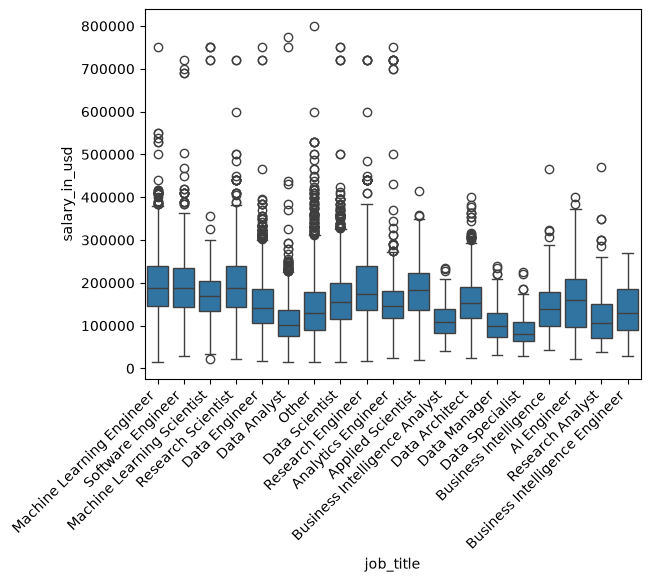

company_size
M    147000.0
L    136000.0
S     75648.0
Name: salary_in_usd, dtype: float64


/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_2889/3980743365.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


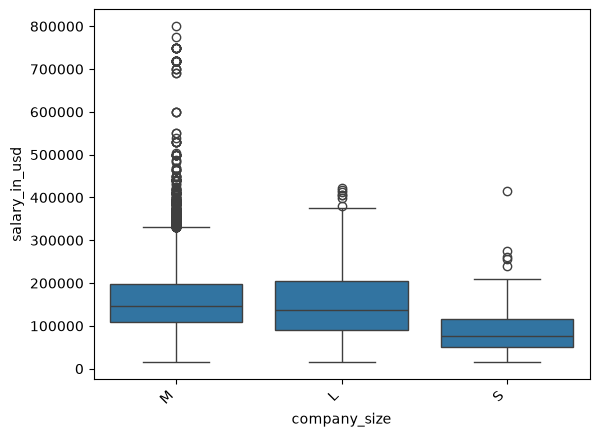

company_region
North_America    150000.0
Middle_East      102500.0
Europe_West       70135.5
Asia_Pacific      70115.0
Latin_America     70000.0
Africa            60000.0
Europe_East       53120.0
Other             38146.0
Name: salary_in_usd, dtype: float64


/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_2889/3980743365.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


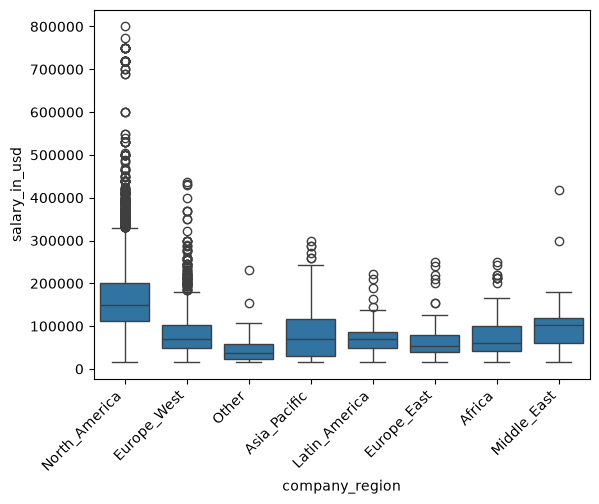

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

output_folder = '../figures'
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    print(df.groupby(col)["salary_in_usd"].median().sort_values(ascending=False))

    # Create the plot
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x=col, y="salary_in_usd", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Dynamic file naming using f-strings
    file_path = f"{output_folder}/boxplot_{col}.png"

    # Save the figure BEFORE plt.show()
    plt.savefig(file_path, dpi=150, bbox_inches='tight')

    plt.show()

    # Clear the current figure for the next loop iteration
    plt.close()

The job title has different spreads, different medians which could indicate a better relationship to predict salary. 
For the company size, the M and L are very similar, the one that stands out is S which has lower median salary.
For the company region, medians are quite similar within two or maybe 3 groups.

To decide whether we could drop a categorigal column, we perform ANOVA test:
    
H0: The mean salary_in_usd is equal across all categories of the column → the column carries no salary signal → candidate to drop.

H1: At least one category mean differs → the column explains some salary variance → keep it.

In [18]:
from scipy.stats import f_oneway

for col in cat_cols:
    groups = [g["salary_in_usd"].values for _, g in X.groupby(col)]
    f, p = f_oneway(*groups)
    print(f"{col:25} F={f:8.1f}  p={p:.2e}")

job_title                 F=   306.4  p=0.00e+00
company_size              F=   109.2  p=5.70e-48
company_region            F=   349.0  p=0.00e+00


We reject H0 for all three columns (p < 0.05), so each explains some salary variance — we keep all categorical columns.

> Ranking by F-statistic (strength, not just significance): `company_region` (F=349) and `job_title` (F=306) separate salaries most strongly; `company_size` (F=109) is real but weakest.

## 5. Preprocessing & Train/Test Split

> Extract features and target, split into train/test, one-hot encode the nominal columns, then standardize.

In [19]:
def features_target_extract(df, drop_cols, target_col):
    df_model = df.drop(columns=drop_cols, errors='ignore')
    if target_col in df_model.columns:
        features = df_model.drop(columns=[target_col])
        target = df_model[target_col]
        return df_model, features, target
    else:
        # test set: no target — return features only
        print('No target column; returning features only')
        return df_model, df_model, None

In [20]:
X, features, target = features_target_extract(X, [], 'salary_in_usd')


In [21]:
display(X.head(2))
display(features.head(2))
display(target)

,job_title,company_size,company_region,companyloc_residence,work_year,salary_in_usd
0,Machine Learning Engineer,M,North_America,True,2024,200200
1,Machine Learning Engineer,M,North_America,True,2024,186915


,job_title,company_size,company_region,companyloc_residence,work_year
0,Machine Learning Engineer,M,North_America,True,2024
1,Machine Learning Engineer,M,North_America,True,2024


0        200200
1        186915
2        240240
3        221596
4        240240
          ...  
29557    412000
29558    151000
29559    105000
29560    100000
29561     94665
Name: salary_in_usd, Length: 29562, dtype: int64

**Perform Train Test Split**

In [22]:
X_train,X_test, y_train,y_test = train_test_split(features,target,test_size=0.2, random_state=0)
display(X_train.head(2))
display(X_test.head(2))

,job_title,company_size,company_region,companyloc_residence,work_year
5725,Data Engineer,M,North_America,True,2024
11242,Data Engineer,M,North_America,True,2024


,job_title,company_size,company_region,companyloc_residence,work_year
11279,Machine Learning Engineer,M,North_America,True,2024
28845,Data Analyst,M,Europe_West,True,2022


- For non-numerical columns, do dummies.

In [23]:
nonnum_cols = ['job_title','company_size','company_region'] # work_year and comploc_residence are treated as number by Skylern.


In [24]:
def dummies_catcols(X_train,X_test,nonnum_cols):
    #dummies for non-numerical columns, for feature train data
    from sklearn.preprocessing import OneHotEncoder
    ohe = OneHotEncoder(sparse_output=False, drop='first') # To avoid having an sparse_matrix as output
    
    ohe.fit(X_train[nonnum_cols]) # The .fit() method determines the unique values of each column
    X_train_dummified_np = ohe.transform(X_train[nonnum_cols])
    X_train_dummified_df = pd.DataFrame(X_train_dummified_np, columns = ohe.get_feature_names_out(nonnum_cols), index=X_train.index)
    
    #Now for the test set
    X_test_dummified_np = ohe.transform(X_test[nonnum_cols])
    X_test_dummified_df=pd.DataFrame(X_test_dummified_np, columns=ohe.get_feature_names_out(nonnum_cols), index=X_test.index)    
    
    return X_train_dummified_df, X_test_dummified_df

In [25]:
X_train_trans_df, X_test_trans_df = dummies_catcols(X_train,X_test,nonnum_cols)

In [26]:
#functions standarizing dummies
def df_full_standarized(X_train_dumm,X_test_dumm,X_train_num,X_test_num):
    dfX_train_full = pd.concat([X_train_dumm, X_train_num], axis=1)
    dfX_test_full  = pd.concat([X_test_dumm, X_test_num], axis=1)
    
    from sklearn.preprocessing import StandardScaler
    
    std_scaler = StandardScaler()
    std_scaler.fit(dfX_train_full)
    
    dfX_train_full_np = std_scaler.transform(dfX_train_full)
    dfX_test_full_np = std_scaler.transform(dfX_test_full)
    
    dfX_train_full_np_df = pd.DataFrame(dfX_train_full_np, columns=dfX_train_full.columns, index=dfX_train_full.index)
    dfX_test_full_np_df  = pd.DataFrame(dfX_test_full_np, columns=dfX_test_full.columns, index=dfX_test_full.index)

    return dfX_train_full_np_df, dfX_test_full_np_df


In [27]:
#Combining data again
num_cols= ['work_year'] # which columns are treated as numerical from the data set for the model
X_train_num = X_train[num_cols]  
X_test_num = X_test[num_cols]  

X_train_full_np_df, X_test_full_np_df = df_full_standarized(X_train_trans_df,X_test_trans_df,X_train_num,X_test_num)

In [28]:
#To tune the model we  will see if dropping companyloc improves the model or not.
X_train_set1 = pd.concat([X_train_full_np_df, X_train['companyloc_residence']], axis=1)
X_test_set1  = pd.concat([X_test_full_np_df,  X_test['companyloc_residence']], axis=1)

X_train_set2 = X_train_full_np_df
X_test_set2 = X_test_full_np_df


In [29]:
print(X_train_set1.dtypes)
print(X_train_set1.shape)

job_title_Analytics Engineer                float64
job_title_Applied Scientist                 float64
job_title_Business Intelligence             float64
job_title_Business Intelligence Analyst     float64
job_title_Business Intelligence Engineer    float64
job_title_Data Analyst                      float64
job_title_Data Architect                    float64
job_title_Data Engineer                     float64
job_title_Data Manager                      float64
job_title_Data Scientist                    float64
job_title_Data Specialist                   float64
job_title_Machine Learning Engineer         float64
job_title_Machine Learning Scientist        float64
job_title_Other                             float64
job_title_Research Analyst                  float64
job_title_Research Engineer                 float64
job_title_Research Scientist                float64
job_title_Software Engineer                 float64
company_size_M                              float64
company_size

In [30]:
print(X_train_full_np_df.shape)
print(X_train_full_np_df[['work_year']].isna().sum())

(23649, 28)
work_year    0
dtype: int64


## 6. Modelling

In [31]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

### 6.1 KNeighbors Regressor

In [32]:
def knn_modelling(train_df, test_df, y_train, y_test):
    knn = KNeighborsRegressor()
    knn.fit(train_df, y_train)
    return f"The R2 of the model is {knn.score(test_df, y_test):.2f}"

In [33]:
# Version A: with companyloc_residence
result_a = knn_modelling(X_train_set1, X_test_set1, y_train, y_test)

# Version B: drop the column from both train and test
result_b = knn_modelling(X_train_set2, X_test_set2, y_train, y_test)

print(f'VersionA: {result_a}')
print(f'VersionB: {result_b}')

VersionA: The R2 of the model is 0.20
VersionB: The R2 of the model is 0.19


### 6.2 Linear Regression

In [34]:
def linear_regmodelling(train_df, test_df, y_train, y_test):

    lin_reg = LinearRegression()
    lin_reg.fit(train_df, y_train) # Determines the b0 and b1's values
    y_pred_test_lr = lin_reg.predict(test_df)
    print(f"MAE {mean_absolute_error(y_pred_test_lr, y_test): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
    print(f"MSE,  {mean_squared_error(y_pred_test_lr, y_test): .2f}")  # mean( (y_test - y_pred_test)^2 )
    print(f"RMSE, {root_mean_squared_error(y_pred_test_lr, y_test): .2f}") # sqrt(MSE), same units as salary_in_usd
    print(f"R2 score, {lin_reg.score(test_df, y_test): .2f}")
    return y_pred_test_lr

In [35]:
# Version A: with companyloc_residence
print('Version A: with companyloc_residence')
linear_regmodelling(X_train_set1, X_test_set1, y_train, y_test)

# Version B: drop the column from both train and test
print('=============')
print('Version B: without companyloc_residence')
linear_regmodelling(X_train_set2, X_test_set2, y_train, y_test)

Version A: with companyloc_residence
MAE  46456.19
MSE,   3795071623.84
RMSE,  61604.15
R2 score,  0.24
Version B: without companyloc_residence
MAE  46410.64
MSE,   3793760498.42
RMSE,  61593.51
R2 score,  0.24


array([200477.57826526,  47686.88357509, 196388.91216776, ...,
       167642.44663318, 153445.40259653, 114519.83354091], shape=(5913,))

### 6.3 Random Forests

In [36]:
def RanForeRegr_modelling(train_df, test_df, y_train, y_test):
    PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42}
    
    rf = RandomForestRegressor(**PARAMS).fit(train_df,y_train)
 
    y_pred = rf.predict(test_df)
    r2_rf = rf.score(test_df, y_test)

    print(f"  R2 Score: {r2_rf:.4f}")
    print(f"  MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"  MSE:      {mean_squared_error(y_test, y_pred):.2f}")
    print(f"  RMSE:     {root_mean_squared_error(y_test, y_pred):.2f}")  

    return y_pred

In [37]:
# ==========================================
# Version A: with companyloc_residence
# ==========================================

rf_a = RanForeRegr_modelling(X_train_set1, X_test_set1, y_train, y_test)
print('=================')

# ==========================================
# Version B: drop the column
# ==========================================est

rf_b = RanForeRegr_modelling(X_train_set2, X_test_set2, y_train, y_test)

  R2 Score: 0.2391
  MAE:      46271.65
  MSE:      3800621368.06
  RMSE:     61649.18
  R2 Score: 0.2407
  MAE:      46253.68
  MSE:      3792608232.38
  RMSE:     61584.16


### 6.4 Bagging Regressor - Random Forests

In [38]:
def bagreg_RanForeRegr_modelling(train_df, test_df, y_train, y_test):
    PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42}
    
    bagrf = BaggingRegressor(RandomForestRegressor(**PARAMS)).fit(train_df,y_train)
 
    y_pred = bagrf.predict(test_df)
    r2_bagrf = bagrf.score(test_df, y_test)

    print(f"  R2 Score: {r2_bagrf:.4f}")
    print(f"  MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"  MSE:      {mean_squared_error(y_test, y_pred):.2f}")
    print(f"  RMSE:     {root_mean_squared_error(y_test, y_pred):.2f}")  

    return y_pred

In [39]:
# ==========================================
# Version A: with companyloc_residence
# ==========================================

bagr_a = bagreg_RanForeRegr_modelling(X_train_set1, X_test_set1, y_train, y_test)
print('=================')

# ==========================================
# Version B: drop the column
# ==========================================est

bagr_b = bagreg_RanForeRegr_modelling(X_train_set2, X_test_set2, y_train, y_test)

  R2 Score: 0.2399
  MAE:      46256.84
  MSE:      3796271493.24
  RMSE:     61613.89
  R2 Score: 0.2422
  MAE:      46218.28
  MSE:      3784876031.94
  RMSE:     61521.35


Version B — without companyloc_residence
  KNN            R2=0.1853   MAE=47,553
  Linear Reg     R2=0.2404   MAE=46,411
  Random Forest  R2=0.2407   MAE=46,254
  Bagging-RF     R2=0.2399   MAE=46,300


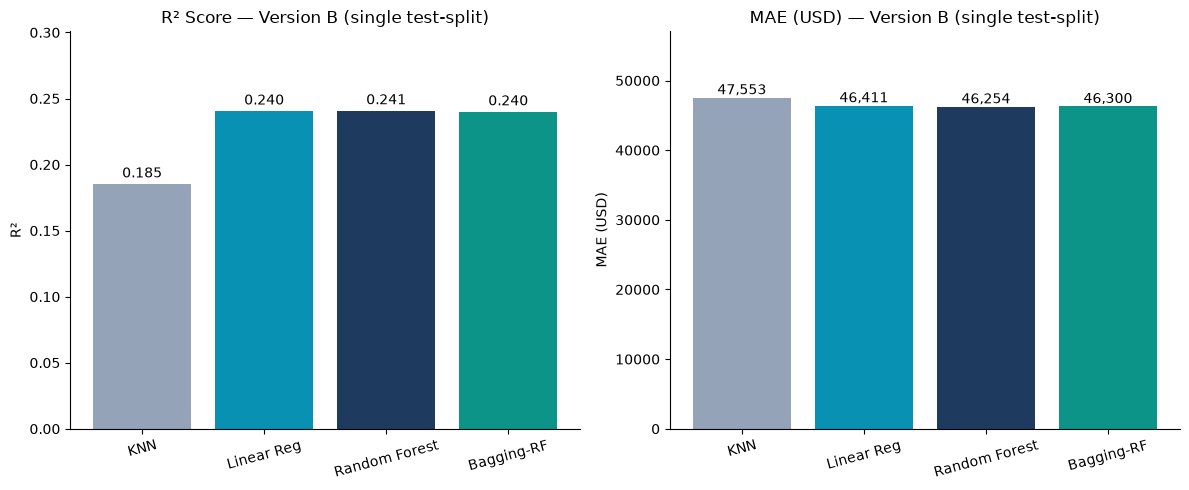

In [40]:
# Plots Version B (without companyloc_residence) R² and MAE for all 4 models.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# --- KNN (Version B) ---
knn_b = KNeighborsRegressor()
knn_b.fit(X_train_set2, y_train)
y_pred_knn_b = knn_b.predict(X_test_set2)

# --- Linear Regression (Version B) ---
lin_b = LinearRegression()
lin_b.fit(X_train_set2, y_train)
y_pred_lin_b = lin_b.predict(X_test_set2)

# --- Random Forest (Version B) — same PARAMS as RanForeRegr_modelling ---
RF_PARAMS = {'n_estimators': 100, 'max_depth': 20, 'random_state': 42}
rf_b_model = RandomForestRegressor(**RF_PARAMS)
rf_b_model.fit(X_train_set2, y_train)
y_pred_rf_b = rf_b_model.predict(X_test_set2)

# --- Bagging Regressor / RF (Version B) — same PARAMS ---
bagrf_b_model = BaggingRegressor(RandomForestRegressor(**RF_PARAMS))
bagrf_b_model.fit(X_train_set2, y_train)
y_pred_bagrf_b = bagrf_b_model.predict(X_test_set2)

# --- Collecting metrics ---
model_results_b = {
    "KNN":             (r2_score(y_test, y_pred_knn_b),    mean_absolute_error(y_test, y_pred_knn_b)),
    "Linear Reg":      (r2_score(y_test, y_pred_lin_b),    mean_absolute_error(y_test, y_pred_lin_b)),
    "Random Forest":   (r2_score(y_test, y_pred_rf_b),     mean_absolute_error(y_test, y_pred_rf_b)),
    "Bagging-RF":      (r2_score(y_test, y_pred_bagrf_b),  mean_absolute_error(y_test, y_pred_bagrf_b)),
}

models = list(model_results_b.keys())
r2_vals  = [model_results_b[m][0] for m in models]
mae_vals = [model_results_b[m][1] for m in models]

print("Version B — without companyloc_residence")
for m in models:
    print(f"  {m:<14} R2={model_results_b[m][0]:.4f}   MAE={model_results_b[m][1]:,.0f}")

# --- Plot: R2 and MAE side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#94A3B8", "#0891B2", "#1E3A5F", "#0D9488"]

axes[0].bar(models, r2_vals, color=colors)
axes[0].set_title("R² Score — Version B (single test-split)", fontsize=12)
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, max(r2_vals) * 1.25)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

axes[1].bar(models, mae_vals, color=colors)
axes[1].set_title("MAE (USD) — Version B (single test-split)", fontsize=12)
axes[1].set_ylabel("MAE (USD)")
axes[1].set_ylim(0, max(mae_vals) * 1.2)
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + max(mae_vals) * 0.01, f"{v:,.0f}", ha="center", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save the figure BEFORE plt.show() — same pattern used earlier in this notebook
fig.savefig("../figures/R2_MAE_VersionB_comparison.png", dpi=150, bbox_inches="tight")

plt.show()

## 7. Model Selection - Conclusion


After performing KNeighbors Regressor and Linear Regressor as the two distance predictors models, and Random Forests then Bagging Regressor with the same Random Forest model parameters, we see that, among the distance-based predictors, Linear Regression performed best, followed by Bagging Regressor - Random Forest. Linear Regression's R2 is unchanged across both versions (0.24) but its MAE improves marginally without `companyloc_residence`. Bagging-RF's R2 is actually marginally higher WITH the column (0.2408 vs 0.2404) -- the difference is within noise either way, so this is not a meaningful driver for model selection.

Thus, for the next phase we will focus on optimising these two model families (Linear Regression and Random Forest / Bagging-RF), independent of the `companyloc_residence` decision.

In [ ]:
#exporting the dataset clean to work with:
def out_csv(df,yaml_path,output_section_yaml,file_name):
    try:
        with open(yaml_path, "r") as file:
            cfg = yaml.safe_load(file)
    except:
        print("Yaml configuration file not found!")
        return None
        
    df.to_csv(cfg[output_section_yaml][file_name], index=False)
    print(f"File saved to: {cfg[output_section_yaml][file_name]}")

In [ ]:
#exporting csv to the clean data folder as specified with the yaml file:   file2: "../data/clean/digfootpring_groups_clean.csv"

yaml_path= "../config.yaml"
output_section_yaml='output_data'
out_file_name= 'file1'    
#droping the column we said to discard:
X = X.drop(columns=['companyloc_residence'])
#exporting file:
out_csv(X,yaml_path,output_section_yaml,out_file_name)